In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('D:\Infosys_Springboard\CreditPathAI\CreditPathAI\data\Loan_Default2.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [6]:

df.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

In [7]:

df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [9]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [10]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [11]:
df.nunique()

LoanID            255347
Age                   52
Income            114620
LoanAmount        158729
CreditScore          550
MonthsEmployed       120
NumCreditLines         4
InterestRate        2301
LoanTerm               5
DTIRatio              81
Education              4
EmploymentType         4
MaritalStatus          3
HasMortgage            2
HasDependents          2
LoanPurpose            5
HasCoSigner            2
Default                2
dtype: int64

In [12]:
df.duplicated().value_counts()

False    255347
Name: count, dtype: int64

In [13]:
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score

#models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [14]:
df.drop('LoanID',axis = 1,inplace = True)

In [15]:
cat_cols = df.select_dtypes(include=['object']).columns
label_encoder = LabelEncoder()
for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [16]:
X = df.drop('Default',axis = 1)
y = df['Default']
print("\nFeatures (X) shape:", X.shape)
print("Target (y) shape:", y.shape)


Features (X) shape: (255347, 16)
Target (y) shape: (255347,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (204277, 16)
Testing set shape: (51070, 16)


In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print("Before Resampling:", y_train.value_counts(normalize=True))
print("After Resampling:", y_train_res.value_counts(normalize=True))
     

Before Resampling: Default
0    0.883873
1    0.116127
Name: proportion, dtype: float64
After Resampling: Default
0    0.5
1    0.5
Name: proportion, dtype: float64


In [21]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier( ),
    "Naive Bayes": GaussianNB()
}

--- Training Logistic Regression ---
Logistic Regression trained successfully.

--- Training Random Forest ---
Random Forest trained successfully.

--- Training XGBoost ---
XGBoost trained successfully.

--- Training K-Nearest Neighbors ---
K-Nearest Neighbors trained successfully.

--- Training Decision Tree ---
Decision Tree trained successfully.

--- Training Naive Bayes ---
Naive Bayes trained successfully.


--- Evaluation for Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     45139
           1       0.22      0.69      0.34      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.74     51070

ROC-AUC Score: 0.7498


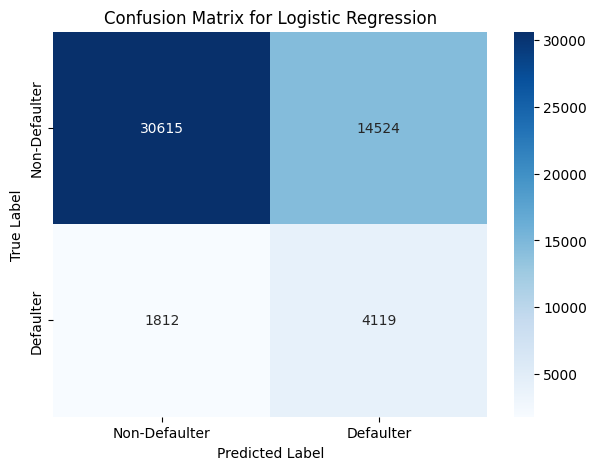


--- Evaluation for Random Forest ---
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     45139
           1       0.40      0.14      0.21      5931

    accuracy                           0.88     51070
   macro avg       0.65      0.56      0.57     51070
weighted avg       0.84      0.88      0.85     51070

ROC-AUC Score: 0.7308


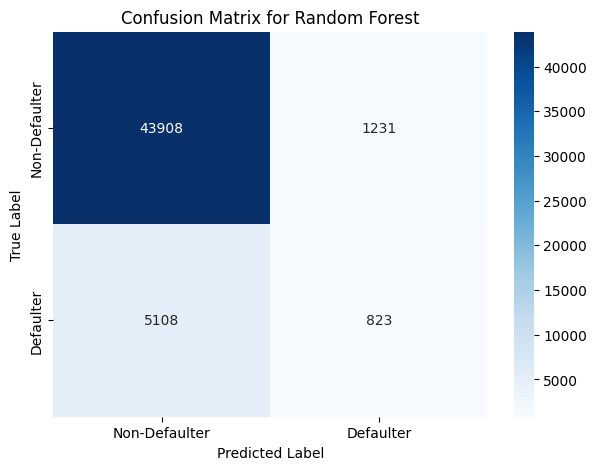


--- Evaluation for XGBoost ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.56      0.09      0.15      5931

    accuracy                           0.89     51070
   macro avg       0.73      0.54      0.54     51070
weighted avg       0.85      0.89      0.85     51070

ROC-AUC Score: 0.7478


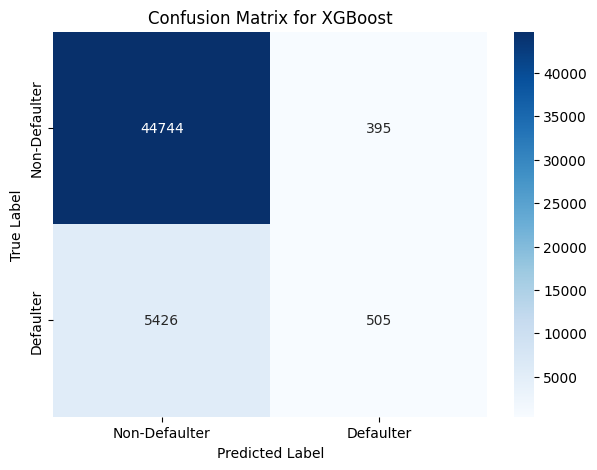


--- Evaluation for K-Nearest Neighbors ---
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.68      0.78     45139
           1       0.17      0.51      0.26      5931

    accuracy                           0.66     51070
   macro avg       0.54      0.59      0.52     51070
weighted avg       0.83      0.66      0.72     51070

ROC-AUC Score: 0.6287


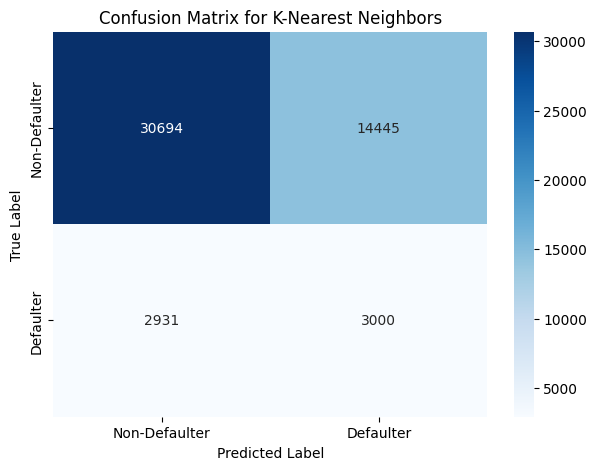


--- Evaluation for Decision Tree ---
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87     45139
           1       0.18      0.28      0.22      5931

    accuracy                           0.77     51070
   macro avg       0.54      0.56      0.54     51070
weighted avg       0.82      0.77      0.79     51070

ROC-AUC Score: 0.5573


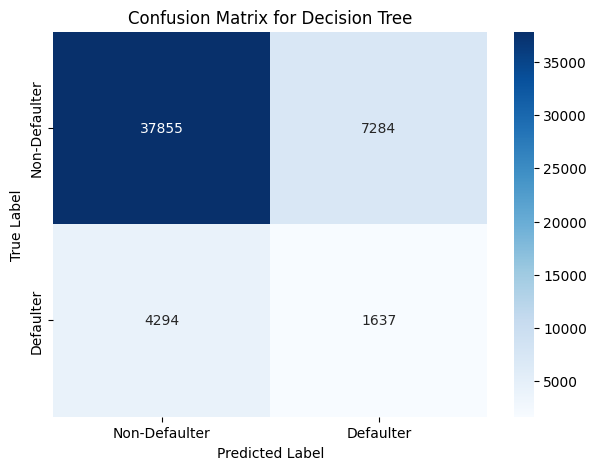


--- Evaluation for Naive Bayes ---
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     45139
           1       0.22      0.68      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.68      0.56     51070
weighted avg       0.86      0.68      0.74     51070

ROC-AUC Score: 0.7435


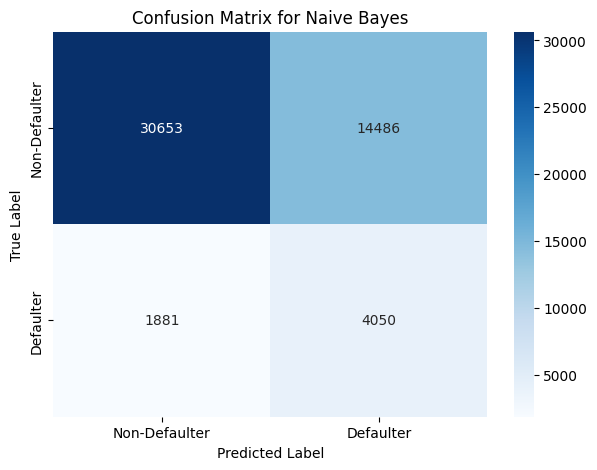

In [23]:
for name, model in models.items():
    print(f"--- Training {name} ---")
    model.fit(X_train_res, y_train_res)  # X_train_res and y_train_res are after SMOTE
    print(f"{name} trained successfully.\n")

# ---------------------------
# Step 3: Evaluate models
# ---------------------------
for name, model in models.items():
    print(f"\n--- Evaluation for {name} ---")
    
    # Predict on test set
    y_pred = model.predict(X_test_scaled)  # Use scaled test set
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # for ROC-AUC

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # ROC-AUC Score
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC-AUC Score: {auc_score:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Defaulter', 'Defaulter'], 
                yticklabels=['Non-Defaulter', 'Defaulter'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [27]:
# ---------------------------
# Step 4: Collect results in tabular form
# ---------------------------
import pandas as pd
from tabulate import tabulate

# Create a results list
results = []

for name, model in models.items():
    # Predict on test set
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Classification report (dictionary)
    report = classification_report(y_test, y_pred, output_dict=True)

    # ROC-AUC Score
    auc_score = roc_auc_score(y_test, y_pred_proba)

    # Append metrics to results
    results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "AUC": auc_score
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print results in table form
print("\n\nFinal Results Summary (Tabular Form):")
print(tabulate(results_df, headers="keys", tablefmt="grid"))




Final Results Summary (Tabular Form):
+----+---------------------+------------+----------+
|    | Model               |   Accuracy |      AUC |
+====+=====================+============+==========+
|  0 | Logistic Regression |   0.680125 | 0.7498   |
+----+---------------------+------------+----------+
|  1 | Random Forest       |   0.875876 | 0.730841 |
+----+---------------------+------------+----------+
|  2 | XGBoost             |   0.886019 | 0.747833 |
+----+---------------------+------------+----------+
|  3 | K-Nearest Neighbors |   0.659761 | 0.628709 |
+----+---------------------+------------+----------+
|  4 | Decision Tree       |   0.773292 | 0.55732  |
+----+---------------------+------------+----------+
|  5 | Naive Bayes         |   0.679518 | 0.743488 |
+----+---------------------+------------+----------+
